In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.neural_network import MLPClassifier

# 1. Path Set
base_path = r'C:\Users\dhanw\Downloads\part_2_cnn_computer_vision-20260508T210831Z-3-001\part_2_cnn_computer_vision'
csv_path = os.path.join(base_path, 'labels.csv')

df = pd.read_csv(csv_path)

# 2. Images loading function
def load_images(df):
    data = []
    valid_labels = []
    for idx, row in df.iterrows():
        img_full_path = os.path.join(base_path, row['filename'])
        img = cv2.imread(img_full_path)
        
        if img is not None:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (64, 64))
            data.append(img.flatten() / 255.0) # Normalization
            valid_labels.append(row['class'])
            
    return np.array(data), np.array(valid_labels)

X, y = load_images(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total images loaded: {len(X)}")

Total images loaded: 480


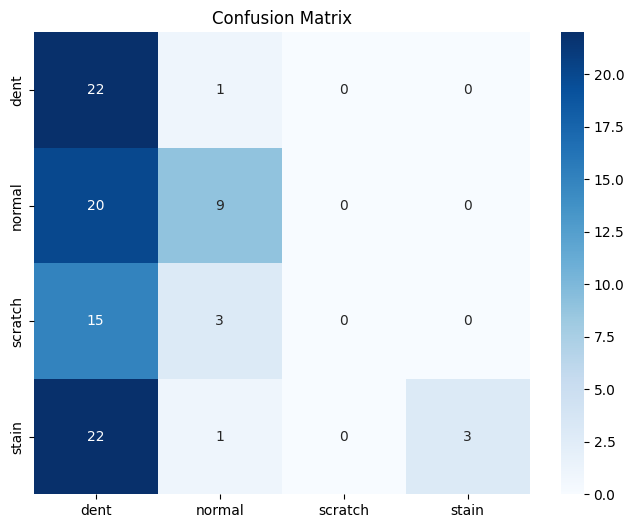

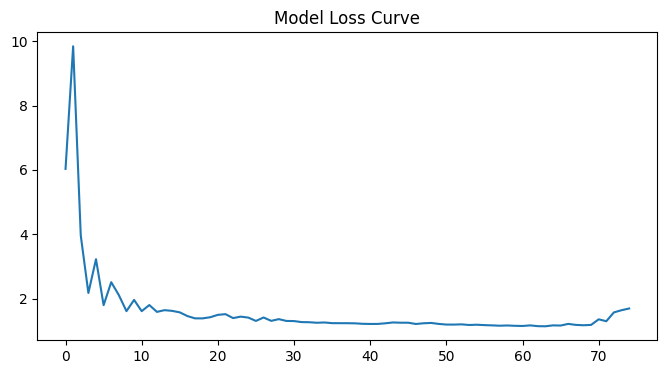

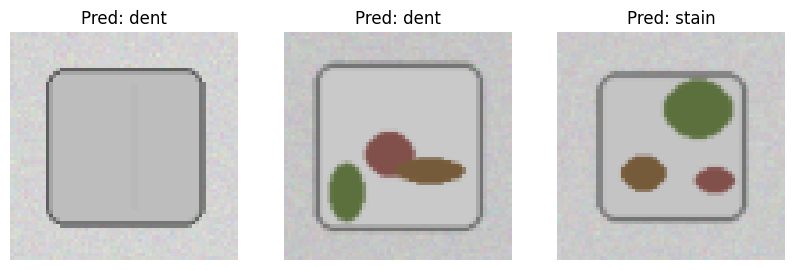

In [9]:
# 1. Model making and training
model = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=300, random_state=42)
model.fit(X_train, y_train)

# 2. Confusion Matrix save in (results/ folder)
plt.figure(figsize=(8, 6))
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=model.classes_, yticklabels=model.classes_, cmap='Blues')
plt.title('Confusion Matrix')
plt.savefig('results/confusion_matrix.png')
plt.show()

# 3. Accuracy Curve saving
plt.figure(figsize=(8, 4))
plt.plot(model.loss_curve_)
plt.title('Model Loss Curve')
plt.savefig('results/accuracy_loss_curves.png')
plt.show()

# 4. Predictions sample saving
plt.figure(figsize=(10, 5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.imshow(X_test[i].reshape(64, 64, 3))
    plt.title(f"Pred: {y_pred[i]}")
    plt.axis('off')
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()